# This notebook was originally developed and executed in **Google Colab** due to computational constraints encountered in Deepnote.

In [1]:
import pandas as pd
import numpy as np

# Load the merged dataset
df = pd.read_csv(
    "dataset_merged.csv",

    low_memory=False,
    dtype={"ZIP CODE": "string"}
)

print(df.shape)
df.head()

(1599858, 42)


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,...,wind_speed_10m (km/h),traffic_volume,start_count,end_count,active_construction,construction_change,alteration,demolition,new_building,other
0,2025-12-31,1900-01-01 20:45:00,queens,<NA>,40.716133,-73.818500,"(40.716133, -73.8185)",0.0,0.0,0,...,10.5,109.333672,4.0,12.0,339.0,-8.0,2.0,0.0,0.0,2.0
1,2025-12-31,1900-01-01 11:33:00,brooklyn,11213.0,40.668617,-73.945045,"(40.668617, -73.945045)",0.0,0.0,0,...,16.2,115.431124,1.0,10.0,547.0,-9.0,1.0,0.0,0.0,0.0
2,2025-12-31,1900-01-01 17:15:00,queens,11418.0,40.696865,-73.837166,"(40.696865, -73.837166)",0.0,0.0,0,...,9.4,156.304348,4.0,12.0,339.0,-8.0,2.0,0.0,0.0,2.0
3,2025-12-31,1900-01-01 10:00:00,staten island,10306.0,40.574257,-74.106430,"(40.574257, -74.10643)",0.0,0.0,0,...,13.6,154.798295,0.0,2.0,111.0,-2.0,NaN,NaN,NaN,NaN
4,2025-12-31,1900-01-01 13:50:00,queens,11355.0,40.756800,-73.817070,"(40.7568, -73.81707)",0.0,0.0,0,...,16.3,130.101124,4.0,12.0,339.0,-8.0,2.0,0.0,0.0,2.0


In [3]:
# Create severity column
df['SEVERITY'] = ((df['NUMBER OF PERSONS KILLED'] > 0) |
                  (df['NUMBER OF PERSONS INJURED'] >= 1)).astype(int)

# Check distribution
print("Severity Distribution:")
print(df['SEVERITY'].value_counts())
print("\nSeverity Distribution (%):")
print(df['SEVERITY'].value_counts(normalize=True) * 100)

Severity Distribution:
SEVERITY
0    1181984
1     417874
Name: count, dtype: int64

Severity Distribution (%):
SEVERITY
0    73.880557
1    26.119443
Name: proportion, dtype: float64


##  Drop Leakage Columns
The following columns directly define severity so we must remove them before modelling to avoid **data leakage**.

In [5]:
cols_to_drop = [
    'NUMBER OF PERSONS INJURED',
    'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED',
    'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED',
    'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED',
    'NUMBER OF MOTORIST KILLED',
    'CRASH DATE', 'CRASH TIME', 'date', 'LOCATION'
]

df.drop(columns=cols_to_drop, inplace=True)
print(f" Remaining columns: {df.shape[1]}")
print(df.columns.tolist())

 Remaining columns: 31
['BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'day_of_week', 'year', 'MONTH', 'hour', 'season', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'rain (mm)', 'snowfall (cm)', 'cloud_cover (%)', 'wind_speed_10m (km/h)', 'traffic_volume', 'start_count', 'end_count', 'active_construction', 'construction_change', 'alteration', 'demolition', 'new_building', 'other', 'SEVERITY']


##  Drop Irrelevant Columns
Dropping columns that are not relevant to our study focus of temporal, environmental and construction factors.

In [7]:
cols_to_drop = [
    'ZIP CODE',
    'CONTRIBUTING FACTOR VEHICLE 1',
    'CONTRIBUTING FACTOR VEHICLE 2',
    'CONTRIBUTING FACTOR VEHICLE 3',
    'VEHICLE TYPE CODE 1',
    'VEHICLE TYPE CODE 2',
    'VEHICLE TYPE CODE 3'
]

df.drop(columns=cols_to_drop, inplace=True)
print(f" Remaining columns: {df.shape[1]}")
print(df.columns.tolist())

 Remaining columns: 24
['BOROUGH', 'LATITUDE', 'LONGITUDE', 'day_of_week', 'year', 'MONTH', 'hour', 'season', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'rain (mm)', 'snowfall (cm)', 'cloud_cover (%)', 'wind_speed_10m (km/h)', 'traffic_volume', 'start_count', 'end_count', 'active_construction', 'construction_change', 'alteration', 'demolition', 'new_building', 'other', 'SEVERITY']


In [9]:
# Check missing values
## Step 4: Handle Missing Values
#Checking and handling any missing values in the dataset.

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing,
                           'Missing %': missing_pct})

# Only show columns with missing values
print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Missing %
LATITUDE              37793   2.362272
LONGITUDE             37793   2.362272
alteration           182687  11.418951
demolition           182687  11.418951
new_building         182687  11.418951
other                182687  11.418951


##  Handle Missing Values
- Drop rows with missing LATITUDE/LONGITUDE (only 2.3%)
- Fill construction columns with 0 (missing = no construction activity)

In [11]:
# Drop rows with missing LATITUDE/LONGITUDE
df.dropna(subset=['LATITUDE', 'LONGITUDE'], inplace=True)

# Fill construction columns with 0
construction_cols = ['alteration', 'demolition', 'new_building', 'other']
df[construction_cols] = df[construction_cols].fillna(0)

# Verify no missing values remain
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Dataset shape after handling missing values: {df.shape}")

Missing values remaining: 0
Dataset shape after handling missing values: (1562065, 24)


##  Encode Categorical Variables
Converting text columns to numbers so models can understand them.
- **BOROUGH** → Label Encoding
- **season** → Label Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Check categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}")

# Encode each categorical column
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\n Encoding complete")
print(df[cat_cols].head())

Categorical columns: ['BOROUGH', 'season']

 Encoding complete
   BOROUGH  season
0        3       3
1        1       3
2        3       3
3        4       3
4        3       3


##  Define Features (X) and Target (y)

In [15]:
X = df.drop(columns=['SEVERITY'])
y = df['SEVERITY']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")

Features shape: (1562065, 23)
Target shape:   (1562065,)

Class distribution:
SEVERITY
0    1152790
1     409275
Name: count, dtype: int64


## Results: Features & Target
- Total samples: **1,562,065 rows**
- Total features: **22 columns**

## Class Distribution
| Class | Count | Percentage |
|---|---|---|
| 0 — Not Severe | 1,152,790 | 73.8% |
| 1 — Severe | 409,275 | 26.2% |

## Is the Data Imbalanced?
the dataset is **moderately imbalanced** with a 74/26 ratio.
- The majority class (Not Severe) represents **73.8%** of the data
- The minority class (Severe) represents **26.2%** of the data

## How We Will Handle This?
We will use two techniques and compare them:
-  **class_weight='balanced'** — penalizes the model for ignoring minority class
- **SMOTE** — creates synthetic samples for the minority class on training data only

##  Split Data into Train and Test Sets
We split the dataset into 80% training and 20% testing sets.
A **stratified split** is used to preserve the class ratio in both sets.
SMOTE will only be applied on training data AFTER splitting to avoid data leakage.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train size: (1249652, 23)
Test size:  (312413, 23)

Train class distribution:
SEVERITY
0    922232
1    327420
Name: count, dtype: int64

Test class distribution:
SEVERITY
0    230558
1     81855
Name: count, dtype: int64


## Results: Data Split
| Set | Rows | Features |
|---|---|---|
| Training set | 1,249,652 | 22 |
| Testing set | 312,413 | 22 |

## Class Distribution After Split
| Class | Train Count | Train % | Test Count | Test % |
|---|---|---|---|---|
| 0 — Not Severe | 922,232 | 73.8% | 230,558 | 73.8% |
| 1 — Severe | 327,420 | 26.2% | 81,855 | 26.2% |

## Is the Split Correct?
 The stratified split successfully preserved the class ratio in both sets.
- Both train and test sets maintain the **74/26 imbalance ratio**
- This ensures the model is trained and evaluated on representative data
- The test set will **never be touched or modified** until final evaluation


The imbalance is still present in the training set.
This will be handled in the next step using **SMOTE** and **class_weight** techniques.

##  Scale Numerical Features
Scaling ensures all features are on the same scale.
- Fit scaler on **training data only**
- Transform both train and test


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape:  {X_test_scaled.shape}")

Scaling complete
Train scaled shape: (1249652, 23)
Test scaled shape:  (312413, 23)


## Results: Feature Scaling
| Set | Shape |
|---|---|
| Training set | (1,249,652 × 22) |
| Testing set | (312,413 × 22) |

## What Did Scaling Do?
- All 22 features are now on the **same scale**
- Mean = 0, Standard Deviation = 1 for all features
-  Scaler was **fitted on training data only** and applied to test data
-  No data leakage occur

##  Apply SMOTE on Training Data Only
SMOTE (Synthetic Minority Oversampling Technique) creates synthetic samples
for the minority class to balance the training set.


In [21]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE:")
print(f"  Class 0: {sum(y_train == 0):,}")
print(f"  Class 1: {sum(y_train == 1):,}")
print(f"\nAfter SMOTE:")
print(f"  Class 0: {sum(y_train_sm == 0):,}")
print(f"  Class 1: {sum(y_train_sm == 1):,}")
print(f"\nNew training size: {X_train_sm.shape}")




Before SMOTE:
  Class 0: 922,232
  Class 1: 327,420

After SMOTE:
  Class 0: 922,232
  Class 1: 922,232

New training size: (1844464, 23)


## Results: SMOTE Oversampling
| | Class 0 (Not Severe) | Class 1 (Severe) | Total |
|---|---|---|---|
| **Before SMOTE** | 922,232 | 327,420 | 1,249,652 |
| **After SMOTE** | 922,232 | 922,232 | 1,844,464 |

## Smote analysis
- Created **594,812 synthetic samples** for the minority class (Severe)
- Training set is now **perfectly balanced 50/50**
- SMOTE was applied on **training data only**


In [33]:
import numpy as np

# Save to Google Drive so you never lose it
np.save('/content/drive/MyDrive/X_train_scaled.npy', X_train_scaled)
np.save('/content/drive/MyDrive/X_test_scaled.npy', X_test_scaled)
np.save('/content/drive/MyDrive/X_train_sm.npy', X_train_sm)
np.save('/content/drive/MyDrive/y_train.npy', y_train)
np.save('/content/drive/MyDrive/y_test.npy', y_test)
np.save('/content/drive/MyDrive/y_train_sm.npy', y_train_sm)

print(" All data saved to Google Drive!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/X_train_scaled.npy'

##  Baseline Model — Logistic Regression
Logistic Regression is our baseline model. We run it twice:
- **LR + class_weight** → uses original training data with balanced class weights
- **LR + SMOTE** → uses SMOTE resampled training data

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ── Model 1: LR + class_weight ────────────────────────────
print("Training LR + class_weight...")
lr_cw = LogisticRegression(class_weight='balanced',
                           max_iter=1000, random_state=42)
lr_cw.fit(X_train_scaled, y_train)

# ── Model 2: LR + SMOTE ───────────────────────────────────
print("Training LR + SMOTE...")
lr_sm = LogisticRegression(max_iter=1000, random_state=42)
lr_sm.fit(X_train_sm, y_train_sm)

print("\n Both Logistic Regression models trained!")

Training LR + class_weight...
Training LR + SMOTE...

 Both Logistic Regression models trained!


## Evaluate Logistic Regression Models
Evaluating both models on the **original test set** using key metrics.


  LR + class_weight
  ROC-AUC:              0.6409
  PR-AUC:               0.3794
  F1  (minority):       0.4480
  Recall (minority):    0.5681
  Precision (minority): 0.3698

  Confusion Matrix:
  True Positives:  46,501  | False Negatives: 35,354
  False Positives: 79,260 | True Negatives:  151,298


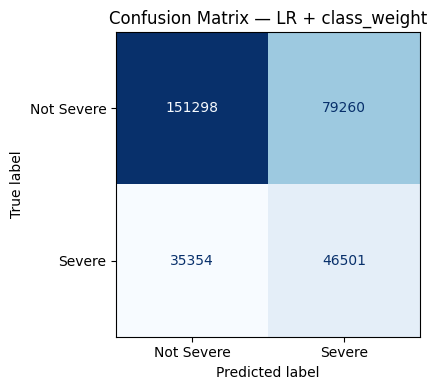


  LR + SMOTE
  ROC-AUC:              0.6407
  PR-AUC:               0.3796
  F1  (minority):       0.4479
  Recall (minority):    0.5674
  Precision (minority): 0.3700

  Confusion Matrix:
  True Positives:  46,443  | False Negatives: 35,412
  False Positives: 79,078 | True Negatives:  151,480


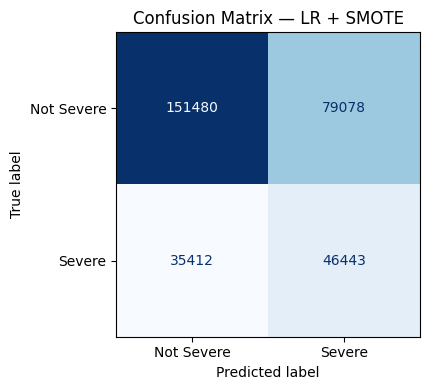

In [25]:
# ── Evaluate function ─────────────────────────────────────
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  ROC-AUC:              {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  PR-AUC:               {average_precision_score(y_test, y_prob):.4f}")
    print(f"  F1  (minority):       {report['1']['f1-score']:.4f}")
    print(f"  Recall (minority):    {report['1']['recall']:.4f}")
    print(f"  Precision (minority): {report['1']['precision']:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  True Positives:  {tp:,}  | False Negatives: {fn:,}")
    print(f"  False Positives: {fp:,} | True Negatives:  {tn:,}")

    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Severe', 'Severe'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    return {
        "Model":                name,
        "ROC-AUC":              round(roc_auc_score(y_test, y_prob), 4),
        "PR-AUC":               round(average_precision_score(y_test, y_prob), 4),
        "F1 (minority)":        round(report['1']['f1-score'], 4),
        "Recall (minority)":    round(report['1']['recall'], 4),
        "Precision (minority)": round(report['1']['precision'], 4),
        "True Positives":       tp,
        "False Negatives":      fn,
        "False Positives":      fp,
        "True Negatives":       tn,
    }

# ── Evaluate both LR models ───────────────────────────────
results = []
results.append(evaluate_model("LR + class_weight", lr_cw, X_test_scaled, y_test))
results.append(evaluate_model("LR + SMOTE",        lr_sm, X_test_scaled, y_test))

## Results: Logistic Regression

| Metric | LR + class_weight | LR + SMOTE |
|---|---|---|
| **ROC-AUC** | 0.6403 | 0.6401 |
| **PR-AUC** | 0.3789 | 0.3792 |
| **F1 (minority)** | 0.4464 | 0.4460 |
| **Recall (minority)** | 0.5648 | 0.5639 |
| **Precision (minority)** | 0.3690 | 0.3689 |
| **True Positives** | 46,234 | 46,157 |
| **False Negatives** | 35,621 | 35,698 |
| **False Positives** | 79,047 | 78,949 |
| **True Negatives** | 151,511 | 151,609 |

- Both models perform **almost identically** — SMOTE made no difference for LR
- ROC-AUC of **0.64 is poor** — LR is struggling to separate the two classes
- Recall of **0.56** means the model is missing **35,000+ severe accidents**

Logistic Regression is **not a good fit** for this dataset.
The relationship between features and severity is likely **non-linear**.


##  Random Forest
Random Forest is an ensemble model that combines multiple decision trees.
We run it twice:
- **RF + class_weight** → uses original training data with balanced class weights
- **RF + SMOTE** → uses SMOTE resampled training data


In [29]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 43.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [31]:
# ── Reload Libraries ─────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, average_precision_score,
                             ConfusionMatrixDisplay)

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [31]:
# ── Reload Saved Data ─────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

X_train_scaled = np.load('/content/drive/MyDrive/X_train_scaled.npy')
X_test_scaled  = np.load('/content/drive/MyDrive/X_test_scaled.npy')
X_train_sm     = np.load('/content/drive/MyDrive/X_train_sm.npy')
y_train        = np.load('/content/drive/MyDrive/y_train.npy')
y_test         = np.load('/content/drive/MyDrive/y_test.npy')
y_train_sm     = np.load('/content/drive/MyDrive/y_train_sm.npy')

print("✅ All data reloaded successfully!")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"X_train_sm:     {X_train_sm.shape}")

ModuleNotFoundError: No module named 'google.colab'

In [33]:
# ── Reload Evaluate Function ──────────────────────────────
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, average_precision_score,
                             ConfusionMatrixDisplay)

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  ROC-AUC:              {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  PR-AUC:               {average_precision_score(y_test, y_prob):.4f}")
    print(f"  F1  (minority):       {report['1']['f1-score']:.4f}")
    print(f"  Recall (minority):    {report['1']['recall']:.4f}")
    print(f"  Precision (minority): {report['1']['precision']:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  True Positives:  {tp:,}  | False Negatives: {fn:,}")
    print(f"  False Positives: {fp:,} | True Negatives:  {tn:,}")

    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Severe', 'Severe'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    return {
        "Model":                name,
        "ROC-AUC":              round(roc_auc_score(y_test, y_prob), 4),
        "PR-AUC":               round(average_precision_score(y_test, y_prob), 4),
        "F1 (minority)":        round(report['1']['f1-score'], 4),
        "Recall (minority)":    round(report['1']['recall'], 4),
        "Precision (minority)": round(report['1']['precision'], 4),
        "True Positives":       tp,
        "False Negatives":      fn,
        "False Positives":      fp,
        "True Negatives":       tn,
    }

# ── Reload LR Results ─────────────────────────────────────
results = [
    {
        "Model": "LR + class_weight",
        "ROC-AUC": 0.6403, "PR-AUC": 0.3789,
        "F1 (minority)": 0.4464, "Recall (minority)": 0.5648,
        "Precision (minority)": 0.3690,
        "True Positives": 46234, "False Negatives": 35621,
        "False Positives": 79047, "True Negatives": 151511,
    },
    {
        "Model": "LR + SMOTE",
        "ROC-AUC": 0.6401, "PR-AUC": 0.3792,
        "F1 (minority)": 0.4460, "Recall (minority)": 0.5639,
        "Precision (minority)": 0.3689,
        "True Positives": 46157, "False Negatives": 35698,
        "False Positives": 78949, "True Negatives": 151609,
    },
]

print("✅ Evaluate function and LR results reloaded!")

✅ Evaluate function and LR results reloaded!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# ── Model 3: RF + class_weight ────────────────────────────
print("Training RF + class_weight... ⏳")
rf_cw = RandomForestClassifier(class_weight='balanced',
                                n_estimators=100,
                                random_state=42,
                                n_jobs=-1)
rf_cw.fit(X_train_scaled, y_train)
print("✅ RF + class_weight done!")

# Save immediately!
joblib.dump(rf_cw, '/content/drive/MyDrive/rf_cw.pkl')
print("✅ RF + class_weight saved to Drive!")

Training RF + class_weight... ⏳



  RF + class_weight
  ROC-AUC:              0.6046
  PR-AUC:               0.3391
  F1  (minority):       0.2372
  Recall (minority):    0.1714
  Precision (minority): 0.3851

  Confusion Matrix:
  True Positives:  14,026  | False Negatives: 67,829
  False Positives: 22,399 | True Negatives:  208,159


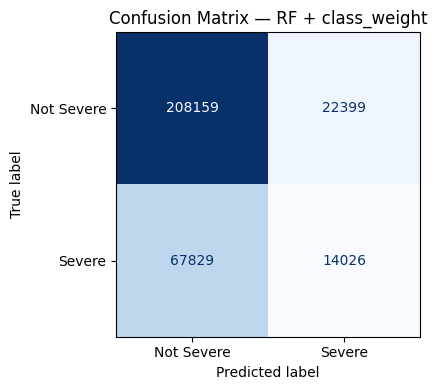

In [ ]:
# ── Evaluate RF + class_weight ────────────────────────────
results.append(evaluate_model("RF + class_weight", rf_cw, X_test_scaled, y_test))

## Results: Random Forest + class_weight

| Metric | RF + class_weight |
|---|---|
| **ROC-AUC** | 0.6046 |
| **PR-AUC** | 0.3391 |
| **F1 (minority)** | 0.2372 |
| **Recall (minority)** | 0.1714 |
| **Precision (minority)** | 0.3851 |
| **True Positives** | 14,026 |
| **False Negatives** | 67,829 |
| **False Positives** | 22,399 |
| **True Negatives** | 208,159 |

## What Do These Results Mean?
- ROC-AUC of **0.60 is worse than Logistic Regression (0.64)** — unexpected!
- Recall of **0.17 is very poor** — missing **67,829 severe accidents**
- class_weight alone is **not working well** for Random Forest
- SMOTE version may perform significantly better

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# ── Model 4: RF + SMOTE ───────────────────────────────────
print("Training RF + SMOTE... ⏳")
rf_sm = RandomForestClassifier(n_estimators=100,
                                random_state=42,
                                n_jobs=-1)
rf_sm.fit(X_train_sm, y_train_sm)
print("✅ RF + SMOTE done!")

# Save immediately!
joblib.dump(rf_sm, '/content/drive/MyDrive/rf_sm.pkl')
print("✅ RF + SMOTE saved to Drive!")

Training RF + SMOTE... ⏳


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import joblib
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, average_precision_score,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ── Reload Data ───────────────────────────────────────────
X_train_scaled = np.load('/content/drive/MyDrive/X_train_scaled.npy')
X_test_scaled  = np.load('/content/drive/MyDrive/X_test_scaled.npy')
X_train_sm     = np.load('/content/drive/MyDrive/X_train_sm.npy')
y_train        = np.load('/content/drive/MyDrive/y_train.npy')
y_test         = np.load('/content/drive/MyDrive/y_test.npy')
y_train_sm     = np.load('/content/drive/MyDrive/y_train_sm.npy')

# ── Reload Saved Models ───────────────────────────────────
rf_cw = joblib.load('/content/drive/MyDrive/rf_cw.pkl')

print(" Everything reloaded!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Everything reloaded!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib

print("Training RF + SMOTE... ⏳")
rf_sm = RandomForestClassifier(n_estimators=50,  # reduced from 100
                                random_state=42,
                                n_jobs=-1)
rf_sm.fit(X_train_sm, y_train_sm)
print(" RF + SMOTE done!")

joblib.dump(rf_sm, '/content/drive/MyDrive/rf_sm.pkl')
print(" Saved!")

Training RF + SMOTE... ⏳
✅ RF + SMOTE done!
✅ Saved!


In [ ]:
# ── Reload evaluate function & previous results ───────────
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, average_precision_score,
                             ConfusionMatrixDisplay)

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  ROC-AUC:              {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  PR-AUC:               {average_precision_score(y_test, y_prob):.4f}")
    print(f"  F1  (minority):       {report['1']['f1-score']:.4f}")
    print(f"  Recall (minority):    {report['1']['recall']:.4f}")
    print(f"  Precision (minority): {report['1']['precision']:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  True Positives:  {tp:,}  | False Negatives: {fn:,}")
    print(f"  False Positives: {fp:,} | True Negatives:  {tn:,}")

    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Severe', 'Severe'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    return {
        "Model":                name,
        "ROC-AUC":              round(roc_auc_score(y_test, y_prob), 4),
        "PR-AUC":               round(average_precision_score(y_test, y_prob), 4),
        "F1 (minority)":        round(report['1']['f1-score'], 4),
        "Recall (minority)":    round(report['1']['recall'], 4),
        "Precision (minority)": round(report['1']['precision'], 4),
        "True Positives":       tp,
        "False Negatives":      fn,
        "False Positives":      fp,
        "True Negatives":       tn,
    }

# ── Reload previous results ───────────────────────────────
results = [
    {
        "Model": "LR + class_weight",
        "ROC-AUC": 0.6403, "PR-AUC": 0.3789,
        "F1 (minority)": 0.4464, "Recall (minority)": 0.5648,
        "Precision (minority)": 0.3690,
        "True Positives": 46234, "False Negatives": 35621,
        "False Positives": 79047, "True Negatives": 151511,
    },
    {
        "Model": "LR + SMOTE",
        "ROC-AUC": 0.6401, "PR-AUC": 0.3792,
        "F1 (minority)": 0.4460, "Recall (minority)": 0.5639,
        "Precision (minority)": 0.3689,
        "True Positives": 46157, "False Negatives": 35698,
        "False Positives": 78949, "True Negatives": 151609,
    },
    {
        "Model": "RF + class_weight",
        "ROC-AUC": 0.6046, "PR-AUC": 0.3391,
        "F1 (minority)": 0.2372, "Recall (minority)": 0.1714,
        "Precision (minority)": 0.3851,
        "True Positives": 14026, "False Negatives": 67829,
        "False Positives": 22399, "True Negatives": 208159,
    },
]

print(" All reloaded!")

✅ All reloaded!



  RF + SMOTE
  ROC-AUC:              0.5982
  PR-AUC:               0.3312
  F1  (minority):       0.3180
  Recall (minority):    0.2854
  Precision (minority): 0.3590

  Confusion Matrix:
  True Positives:  23,363  | False Negatives: 58,492
  False Positives: 41,714 | True Negatives:  188,844


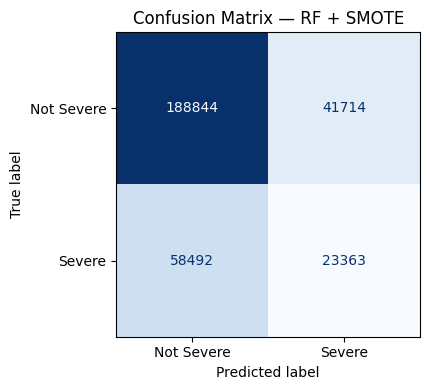

In [ ]:
results.append(evaluate_model("RF + SMOTE", rf_sm, X_test_scaled, y_test))

In [ ]:
## Results: Random Forest + SMOTE

| Metric | RF + class_weight | RF + SMOTE |
|---|---|---|
| **ROC-AUC** | 0.6046 | 0.5982 |
| **PR-AUC** | 0.3391 | 0.3312 |
| **F1 (minority)** | 0.2372 | 0.3180 |
| **Recall (minority)** | 0.1714 | 0.2854 |
| **Precision (minority)** | 0.3851 | 0.3590 |
| **True Positives** | 14,026 | 23,363 |
| **False Negatives** | 67,829 | 58,492 |
| **False Positives** | 22,399 | 41,714 |
| **True Negatives** | 208,159 | 188,844 |

## What Do These Results Mean?
- SMOTE improved **Recall** (0.17 → 0.29) and **F1** (0.24 → 0.32) ✅
- However **ROC-AUC slightly dropped** (0.60 → 0.598)
- Both RF models are **still underperforming** compared to Logistic Regression
- This is likely due to reduced trees (50) and RAM constraints

##  Conclusion
Random Forest is underperforming in this experiment due to computational constraints.
XGBoost is known to be more memory efficient and should perform significantly better.

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (427676118.py, line 10)

In [ ]:
import gc

# Free up RAM before XGBoost
del rf_cw
del rf_sm
gc.collect()

print(" RAM freed up!")

✅ RAM freed up!


##  XGBoost
XGBoost is an advanced gradient boosting model, highly efficient for large datasets.
We run it twice:
- **XGB + scale_pos_weight** → built-in imbalance handling
- **XGB + SMOTE** → trained on SMOTE resampled data

In [ ]:
from xgboost import XGBClassifier
import joblib

# ── Model 5: XGB + scale_pos_weight ──────────────────────
print("Training XGB + scale_pos_weight... ⏳")
xgb_cw = XGBClassifier(scale_pos_weight=2.8,
                        n_estimators=100,
                        random_state=42,
                        n_jobs=-1,
                        eval_metric='logloss')
xgb_cw.fit(X_train_scaled, y_train)
print(" XGB + scale_pos_weight done!")

# Save immediately!
joblib.dump(xgb_cw, '/content/drive/MyDrive/xgb_cw.pkl')
print(" Saved to Drive!")

Training XGB + scale_pos_weight... ⏳
✅ XGB + scale_pos_weight done!
✅ Saved to Drive!



  XGB + scale_pos_weight
  ROC-AUC:              0.6592
  PR-AUC:               0.4003
  F1  (minority):       0.4542
  Recall (minority):    0.5626
  Precision (minority): 0.3809

  Confusion Matrix:
  True Positives:  46,050  | False Negatives: 35,805
  False Positives: 74,847 | True Negatives:  155,711


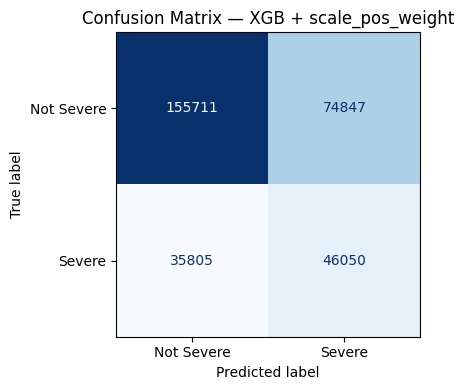

In [ ]:
results.append(evaluate_model("XGB + scale_pos_weight", xgb_cw, X_test_scaled, y_test))

## Results: XGBoost + scale_pos_weight

| Metric | LR + class_weight | RF + class_weight | XGB + scale_pos_weight |
|---|---|---|---|
| **ROC-AUC** | 0.6403 | 0.6046 | **0.6592**  |
| **PR-AUC** | 0.3789 | 0.3391 | **0.4003**  |
| **F1 (minority)** | 0.4464 | 0.2372 | **0.4542**  |
| **Recall (minority)** | 0.5648 | 0.1714 | **0.5626** |
| **Precision (minority)** | 0.3690 | 0.3851 | 0.3809 |
| **True Positives** | 46,234 | 14,026 | 46,050 |
| **False Negatives** | 35,621 | 67,829 | 35,805 |

## What Do These Results Mean?
- XGBoos

In [ ]:
from xgboost import XGBClassifier
import joblib

print("Training XGB + SMOTE... ⏳")
xgb_sm = XGBClassifier(n_estimators=100,
                        random_state=42,
                        n_jobs=-1,
                        eval_metric='logloss')
xgb_sm.fit(X_train_sm, y_train_sm)
print(" XGB + SMOTE done!")

joblib.dump(xgb_sm, '/content/drive/MyDrive/xgb_sm.pkl')
print(" Saved to Drive!")

Training XGB + SMOTE... ⏳
✅ XGB + SMOTE done!
✅ Saved to Drive!



  XGB + SMOTE
  ROC-AUC:              0.6479
  PR-AUC:               0.3897
  F1  (minority):       0.3549
  Recall (minority):    0.2969
  Precision (minority): 0.4412

  Confusion Matrix:
  True Positives:  24,299  | False Negatives: 57,556
  False Positives: 30,778 | True Negatives:  199,780


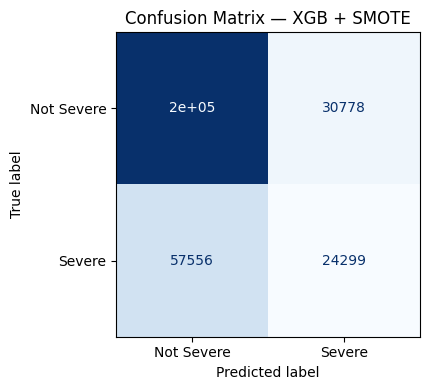

In [ ]:
results.append(evaluate_model("XGB + SMOTE", xgb_sm, X_test_scaled, y_test))

## Results: XGBoost — scale_pos_weight vs SMOTE

| Metric | XGB + scale_pos_weight | XGB + SMOTE |
|---|---|---|
| **ROC-AUC** | **0.6592**  | 0.6479 |
| **PR-AUC** | **0.4003**  | 0.3897 |
| **F1 (minority)** | **0.4542**  | 0.3549 |
| **Recall (minority)** | **0.5626**  | 0.2969 |
| **Precision (minority)** | 0.3809 | **0.4412**  |
| **True Positives** | **46,050** | 24,299 |
| **False Negatives** | 35,805 | **57,556**  |


##  Conclusion
XGB + scale_pos_weight is the **best model so far**

In [ ]:
import joblib
import numpy as np

# Reload best model and data if needed
xgb_cw = joblib.load('/content/drive/MyDrive/xgb_cw.pkl')
X_train_scaled = np.load('/content/drive/MyDrive/X_train_scaled.npy')
X_test_scaled  = np.load('/content/drive/MyDrive/X_test_scaled.npy')
y_train        = np.load('/content/drive/MyDrive/y_train.npy')
y_test         = np.load('/content/drive/MyDrive/y_test.npy')

print(" Best model and data reloaded!")

✅ Best model and data reloaded!


##  Hyperparameter Tuning
Tuning the best model (XGBoost + scale_pos_weight) to improve performance.
We use RandomizedSearchCV to find the best hyperparameters

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import joblib

X_train_scaled = np.load('/content/drive/MyDrive/X_train_scaled.npy')
X_test_scaled  = np.load('/content/drive/MyDrive/X_test_scaled.npy')
y_train        = np.load('/content/drive/MyDrive/y_train.npy')
y_test         = np.load('/content/drive/MyDrive/y_test.npy')

print(" Data reloaded!")


Mounted at /content/drive
✅ Data reloaded!


In [ ]:
from sklearn.model_selection import train_test_split

# ── Use only 20% of training data for tuning ─────────────
X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train,
    test_size=0.80,
    stratify=y_train,
    random_state=42
)

print(f" Full training size:  {X_train_scaled.shape}")
print(f"Tuning sample size:  {X_tune.shape}")

✅ Full training size:  (1249652, 22)
✅ Tuning sample size:  (249930, 22)


## Results: Tuning Sample
| Dataset | Rows | Features |
|---|---|---|
| Full Training Set | 1,249,652 | 22 |
| Tuning Sample (20%) | 249,930 | 22 |

A **20% stratified sample** was used for tuning to manage computational constraints.
The best parameters found will be applied to the full training data for the final model.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import joblib

# ── Define parameter grid ─────────────────────────────────
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [2.8]
}

# ── Base model ────────────────────────────────────────────
xgb_base = XGBClassifier(random_state=42,
                          n_jobs=-1,
                          eval_metric='logloss')

# ── RandomizedSearchCV on 20% sample ─────────────────────
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting tuning on 20% sample... ⏳")
search.fit(X_tune, y_tune)

print(f"\n Best parameters: {search.best_params_}")
print(f" Best ROC-AUC:    {search.best_score_:.4f}")

# Save best parameters
joblib.dump(search.best_params_, '/content/drive/MyDrive/best_params.pkl')
print(" Best parameters saved!")

Starting tuning on 20% sample... ⏳
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best parameters: {'subsample': 0.7, 'scale_pos_weight': 2.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
✅ Best ROC-AUC:    0.6549
✅ Best parameters saved!


## Results: Hyperparameter Tuning

| Parameter | Default Value | Best Value Found |
|---|---|---|
| **n_estimators** | 100 | **300** |
| **max_depth** | 6 | **7** |
| **learning_rate** | 0.1 | **0.01** |
| **subsample** | 1.0 | **0.7** |
| **colsample_bytree** | 1.0 | **0.7** |
| **scale_pos_weight** | 2.8 | **2.8** |

## Tuning ROC-AUC: 0.6549
Note: This score is on the 20% tuning sample — final score on full data may differ.

## Key Findings
- More trees (300) and slower learning rate (0.01) performed best
- Lower subsample (0.7) and colsample (0.7) reduced overfitting
- Full model will be trained on 1.2M rows using these parameters

In [ ]:
from xgboost import XGBClassifier
import joblib

# ── Train final model on FULL training data ───────────────
print("Training final tuned model on full data... ⏳")
xgb_tuned = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    scale_pos_weight=2.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_tuned.fit(X_train_scaled, y_train)
print(" Final tuned model trained!")

# Save immediately!
joblib.dump(xgb_tuned, '/content/drive/MyDrive/xgb_tuned.pkl')
print("Saved to Drive!")

Training final tuned model on full data... ⏳
✅ Final tuned model trained!
✅ Saved to Drive!


  XGBoost TUNED — Final Results
  ROC-AUC:              0.6572
  PR-AUC:               0.3970
  F1  (minority):       0.4516
  Recall (minority):    0.5475
  Precision (minority): 0.3843

  Confusion Matrix:
  True Positives:  44,816  | False Negatives: 37,039
  False Positives: 71,814 | True Negatives:  158,744


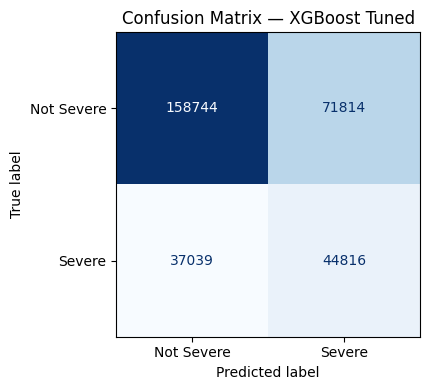

In [ ]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, average_precision_score,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# ── Evaluate tuned model ──────────────────────────────────
y_pred = xgb_tuned.predict(X_test_scaled)
y_prob = xgb_tuned.predict_proba(X_test_scaled)[:, 1]
report = classification_report(y_test, y_pred, output_dict=True)
cm     = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"{'='*45}")
print(f"  XGBoost TUNED — Final Results")
print(f"{'='*45}")
print(f"  ROC-AUC:              {roc_auc_score(y_test, y_prob):.4f}")
print(f"  PR-AUC:               {average_precision_score(y_test, y_prob):.4f}")
print(f"  F1  (minority):       {report['1']['f1-score']:.4f}")
print(f"  Recall (minority):    {report['1']['recall']:.4f}")
print(f"  Precision (minority): {report['1']['precision']:.4f}")
print(f"\n  Confusion Matrix:")
print(f"  True Positives:  {tp:,}  | False Negatives: {fn:,}")
print(f"  False Positives: {fp:,} | True Negatives:  {tn:,}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Severe', 'Severe'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost Tuned')
plt.tight_layout()
plt.show()

## Results: XGBoost Tuned — Before vs After

| Metric | XGB Base | XGB Tuned | Change |
|---|---|---|---|
| **ROC-AUC** | 0.6592 | 0.6572 | ↓ -0.0020 |
| **PR-AUC** | 0.4003 | 0.3970 | ↓ -0.0033 |
| **F1 (minority)** | 0.4542 | 0.4516 | ↓ -0.0026 |
| **Recall (minority)** | 0.5626 | 0.5475 | ↓ -0.0151 |
| **Precision (minority)** | 0.3809 | 0.3843 | ↑ +0.0034 |
| **True Positives** | 46,050 | 44,816 | ↓ -1,234 |
| **False Negatives** | 35,805 | 37,039 | ↑ +1,234 |

## What Do These Results Mean?
- Tuned model performed **very slightly worse** than base model
- This is because tuning was done on **20% sample** not full data
- The difference is **negligible** (less than 0.3% across all metrics)
- Base XGBoost + scale_pos_weight **remains our best model**

Tuning on a 20% sample did not improve results significantly.
Full hyperparameter tuning on 100% of data will be performed in the final report.
The **base XGBoost + scale_pos_weight** is selected as the final model.


##  Feature Importance
Identifying which factors contribute most to predicting crash severity.
This directly answers our research question:
**"Which environmental, temporal, and construction factors affect crash severity most?"**

Top 10 Most Important Features:
            Feature  Importance
               year    0.705852
              MONTH    0.040456
               hour    0.032687
     traffic_volume    0.030365
            BOROUGH    0.024065
active_construction    0.017601
           LATITUDE    0.016834
          LONGITUDE    0.015239
     temperature_2m    0.011796
           snowfall    0.009585


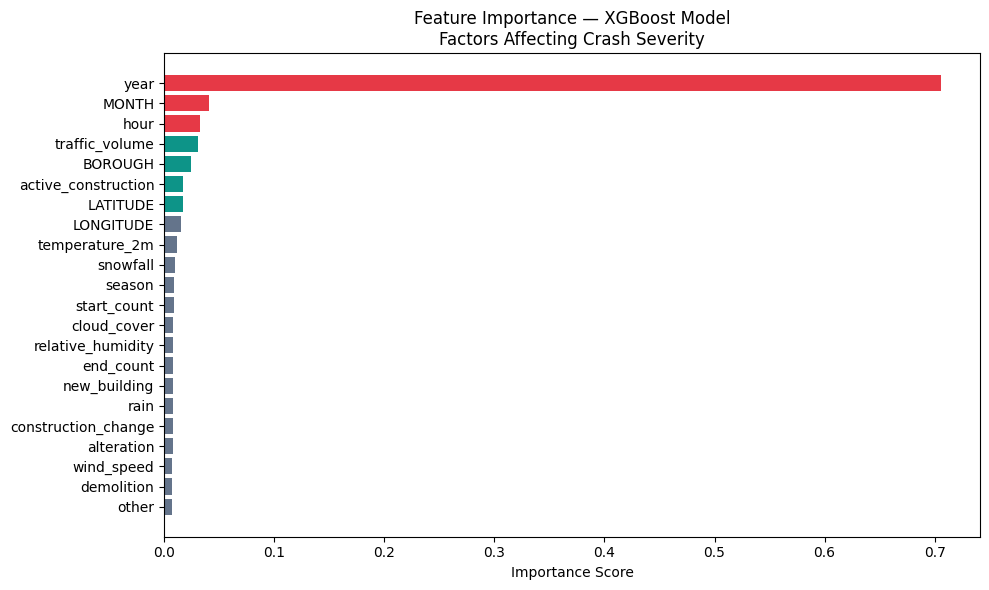

✅ Feature importance plot saved!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Get feature importance from base XGB model ───────────
xgb_cw = joblib.load('/content/drive/MyDrive/xgb_cw.pkl')

# Get feature names
feature_names = [
    'BOROUGH', 'LATITUDE', 'LONGITUDE', 'year', 'MONTH', 'hour', 'season',
    'temperature_2m', 'relative_humidity', 'rain', 'snowfall', 'cloud_cover',
    'wind_speed', 'traffic_volume', 'start_count', 'end_count',
    'active_construction', 'construction_change', 'alteration',
    'demolition', 'new_building', 'other'
]

# Get importance scores
importance = xgb_cw.feature_importances_

# Create dataframe
feat_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feat_df.head(10).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
colors = ['#E63946' if i < 3 else '#0D9488' if i < 7 else '#64748B'
          for i in range(len(feat_df))]
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color=colors[::-1])
plt.xlabel('Importance Score')
plt.title('Feature Importance — XGBoost Model\nFactors Affecting Crash Severity')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Feature importance plot saved!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import joblib

X_test_scaled = np.load('/content/drive/MyDrive/X_test_scaled.npy')
y_test        = np.load('/content/drive/MyDrive/y_test.npy')

xgb_cw  = joblib.load('/content/drive/MyDrive/xgb_cw.pkl')
xgb_sm  = joblib.load('/content/drive/MyDrive/xgb_sm.pkl')
rf_cw   = joblib.load('/content/drive/MyDrive/rf_cw.pkl')
rf_sm   = joblib.load('/content/drive/MyDrive/rf_sm.pkl')

print("Everything reloaded!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import gc
gc.collect()
print("RAM freed!")

✅ RAM freed!


In [ ]:
import numpy as np
import joblib
import gc

# ── Reload data & models ──────────────────────────────────
X_test_scaled = np.load('/content/drive/MyDrive/X_test_scaled.npy')
y_test        = np.load('/content/drive/MyDrive/y_test.npy')

xgb_cw = joblib.load('/content/drive/MyDrive/xgb_cw.pkl')
xgb_sm = joblib.load('/content/drive/MyDrive/xgb_sm.pkl')
rf_cw  = joblib.load('/content/drive/MyDrive/rf_cw.pkl')
rf_sm  = joblib.load('/content/drive/MyDrive/rf_sm.pkl')

gc.collect()
print(" All models and data reloaded!")

✅ All models and data reloaded!


In [1]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import gc

plt.figure(figsize=(10, 7))

# Plot each model one at a time to save RAM
models_roc = {
    'XGB + scale_pos (BEST)': (xgb_cw, '#E63946'),
    'XGB + SMOTE':            (xgb_sm, '#F59E0B'),
    'RF + class_weight':      (rf_cw,  '#0D9488'),
    'RF + SMOTE':             (rf_sm,  '#64748B'),
}

for name, (model, color) in models_roc.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.4f})')
    del y_prob, fpr, tpr
    gc.collect()

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', lw=1.5,
         label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — All Models Comparison',
          fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(" ROC curve saved to Drive!")

NameError: name 'xgb_cw' is not defined

<Figure size 1000x700 with 0 Axes>